**LIBRERÍAS**

In [2]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import struct
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,precision_recall_curve)

**CARGA DEL DATASET**

In [4]:
url = "https://drive.google.com/drive/folders/1mdExsONP4S3b5Czn6nR4cLIdsZGs9zDQ"

gdown.download_folder(
    url,
    output="datasets",
    quiet=False,
    use_cookies=False)


Retrieving folder contents


Processing file 16NciaPpopHYrRp65-6nxihfENTD9h2An t10k-images.idx3-ubyte
Processing file 1YBjmRe5Xeqm-Bx0RPNXTXRjfcvCL9j9_ t10k-labels.idx1-ubyte
Processing file 1L-uWeLya6dEZdfpCZZSjVTTOFh6EPEBD train-images.idx3-ubyte
Processing file 1JkZqSVoh4Nkubq65AWdVc3VRFpquTTGQ train-labels.idx1-ubyte


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=16NciaPpopHYrRp65-6nxihfENTD9h2An
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\t10k-images.idx3-ubyte
100%|██████████| 7.84M/7.84M [00:00<00:00, 31.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YBjmRe5Xeqm-Bx0RPNXTXRjfcvCL9j9_
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\t10k-labels.idx1-ubyte
100%|██████████| 10.0k/10.0k [00:00<00:00, 9.99MB/s]
Downloading...
From: https://drive.google.com/uc?id=1L-uWeLya6dEZdfpCZZSjVTTOFh6EPEBD
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\train-images.idx3-ubyte
100%|██████████| 47.0M/47.0M [00:01<00:00, 33.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JkZqSVoh4Nkubq65AWdVc3VRFpquTTGQ
To: c:\Users\fjm25\Desktop\Facundo\TUIA\AA2\TP1\datasets\train-labels.idx1-ubyte
100%|██████████| 60.0k/60.0k [00:00<00:00, 1.59MB/s]
Download complete

['datasets\\t10k-images.idx3-ubyte',
 'datasets\\t10k-labels.idx1-ubyte',
 'datasets\\train-images.idx3-ubyte',
 'datasets\\train-labels.idx1-ubyte']

In [7]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images

def load_mnist_labels(filepath):
    with open(filepath,'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

base_path = r"DATASETS-PROBLEMA2/"
X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

print(f"X_train: {X_train.shape}") 
print(f"X_test: {X_test.shape}")

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


**APLANDO Y NORMALIZACIÓN**

In [8]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") 
print(f"X_test_flat: {X_test_flat.shape}")

X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_test_flat = X_test_flat.astype(np.float32) / 255.0

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


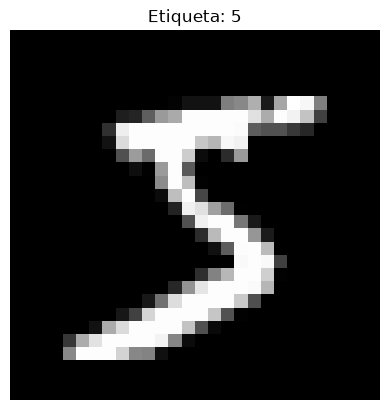

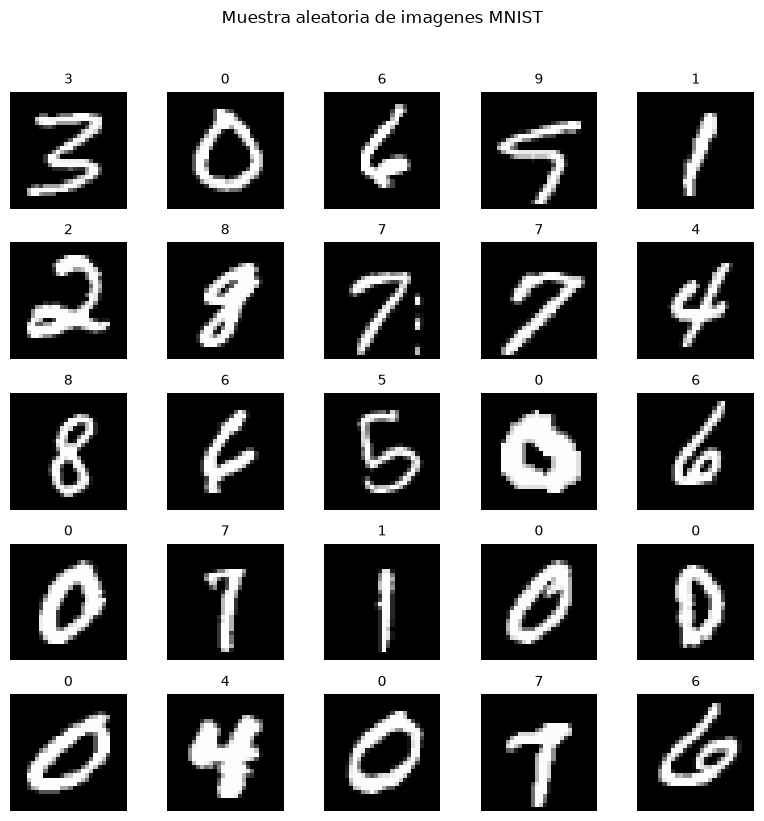

In [9]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

indices = np.random.choice(len(X_train), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()